In [10]:
import pandas as pd
import numpy as np

stations_df = pd.read_csv("data/Delhi-Metro-Network-Cleaned.csv")
print(stations_df.shape)
stations_df.head()

(285, 9)


,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude,Opening Year
0,1,Jhil Mil,10.3,Red line,2008-04-06,Elevated,28.675790,77.312390,2008
1,2,Welcome [Conn: Red],46.8,Pink line,2018-10-31,Elevated,28.671800,77.277560,2018
2,3,DLF Phase 3,10.0,Rapid Metro,2013-11-14,Elevated,28.493600,77.093500,2013
3,4,Okhla NSIC,23.8,Magenta line,2017-12-25,Elevated,28.554483,77.264849,2017
4,5,Dwarka Mor,10.2,Blue line,2005-12-30,Elevated,28.619320,77.033260,2005


In [11]:
interchange_counts = stations_df.groupby("Station Name")["Line"].nunique().reset_index()
interchange_counts.columns = ["Station Name", "Line_Count"]

# Merge back, keep one row per unique station (using the first line listed for reference)
stations_unique = stations_df.drop_duplicates(subset=["Station Name"], keep="first").merge(
    interchange_counts, on="Station Name"
)

print("Stations with most lines (biggest interchanges):")
print(stations_unique.sort_values("Line_Count", ascending=False)[["Station Name", "Line_Count"]].head(10))
print("\nTotal unique stations:", len(stations_unique))

Stations with most lines (biggest interchanges):
                 Station Name  Line_Count
115               Yamuna Bank           2
120           Ashok Park Main           2
178              Jahangirpuri           1
192  Rajiv Chowk [Conn: Blue]           1
191               IFFCO Chowk           1
190  Anand Vihar [Conn: Blue]           1
189          Dwarka Sector 11           1
188    Trilokpuri Sanjay Lake           1
187       Depot Greater Noida           1
0                    Jhil Mil           1

Total unique stations: 283


In [12]:
np.random.seed(42)

records = []
hours = list(range(5, 24))  # metro operates ~5 AM to midnight
days = pd.date_range("2024-01-01", periods=30, freq="D")  # 30 representative days

for _, station in stations_unique.iterrows():
    station_name = station["Station Name"]
    line = station["Line"]
    line_count = station["Line_Count"]

    # Base demand scales with how big an interchange the station is
    base_demand = 150 + (line_count - 1) * 250

    for day in days:
        is_weekend = day.dayofweek >= 5

        for hour in hours:
            if not is_weekend:
                # Weekday: morning peak 8-10, evening peak 17-20
                if 8 <= hour <= 10:
                    multiplier = np.random.uniform(2.5, 3.2)
                elif 17 <= hour <= 20:
                    multiplier = np.random.uniform(2.8, 3.5)
                elif 11 <= hour <= 16:
                    multiplier = np.random.uniform(1.0, 1.4)
                else:
                    multiplier = np.random.uniform(0.3, 0.7)
            else:
                # Weekend: flatter, mild midday bump, no sharp peaks
                if 12 <= hour <= 18:
                    multiplier = np.random.uniform(1.2, 1.7)
                else:
                    multiplier = np.random.uniform(0.5, 0.9)

            noise = np.random.normal(1.0, 0.08)  # +/- 8% random noise
            passengers = max(0, int(base_demand * multiplier * noise))

            records.append({
                "Station_Name": station_name,
                "Line": line,
                "Line_Count": line_count,
                "Date": day,
                "Hour": hour,
                "Day_of_Week": day.day_name(),
                "Is_Weekend": is_weekend,
                "Passengers": passengers,
            })

demand_df = pd.DataFrame(records)
print("Shape:", demand_df.shape)
demand_df.head(10)

Shape: (161310, 8)


,Station_Name,Line,Line_Count,Date,Hour,Day_of_Week,Is_Weekend,Passengers
0,Jhil Mil,Red line,1,2024-01-01,5,Monday,False,61
1,Jhil Mil,Red line,1,2024-01-01,6,Monday,False,55
2,Jhil Mil,Red line,1,2024-01-01,7,Monday,False,49
3,Jhil Mil,Red line,1,2024-01-01,8,Monday,False,485
4,Jhil Mil,Red line,1,2024-01-01,9,Monday,False,359
5,Jhil Mil,Red line,1,2024-01-01,10,Monday,False,377
6,Jhil Mil,Red line,1,2024-01-01,11,Monday,False,133
7,Jhil Mil,Red line,1,2024-01-01,12,Monday,False,180
8,Jhil Mil,Red line,1,2024-01-01,13,Monday,False,180
9,Jhil Mil,Red line,1,2024-01-01,14,Monday,False,161


In [13]:
import re

def extract_base_name(name):
    # Strip anything from " [Conn:" onward
    return re.sub(r"\s*\[Conn:.*\]", "", name).strip()

def extract_connections(name):
    match = re.search(r"\[Conn:\s*(.*?)\]", name)
    if match:
        return [c.strip() for c in match.group(1).split(",")]
    return []

stations_df["Base_Station_Name"] = stations_df["Station Name"].apply(extract_base_name)
stations_df["Connections"] = stations_df["Station Name"].apply(extract_connections)

# True line count = 1 (its own line) + however many other lines it connects to
stations_df["True_Line_Count"] = stations_df["Connections"].apply(len) + 1

# Now group by the BASE name to get one row per real physical station
stations_unique = stations_df.sort_values("True_Line_Count", ascending=False).drop_duplicates(
    subset=["Base_Station_Name"], keep="first"
)

print("Top 10 real interchanges:")
print(stations_unique.sort_values("True_Line_Count", ascending=False)[["Base_Station_Name", "Line", "True_Line_Count"]].head(10))
print("\nTotal unique physical stations:", len(stations_unique))

Top 10 real interchanges:
       Base_Station_Name          Line  True_Line_Count
66         Kashmere Gate      Red line                3
49             Hauz Khas  Magenta line                2
184          Sikandarpur   Yellow line                2
172          Dhaula Kuan   Orange line                2
5         Dilli Haat INA     Pink line                2
279             Inderlok      Red line                2
278     Dwarka Sector 21   Orange line                2
213            New Delhi   Yellow line                2
201         Lajpat Nagar     Pink line                2
199  Netaji Subash Place      Red line                2

Total unique physical stations: 262


In [14]:
np.random.seed(42)

records = []
hours = list(range(5, 24))
days = pd.date_range("2024-01-01", periods=30, freq="D")

for _, station in stations_unique.iterrows():
    station_name = station["Base_Station_Name"]
    line = station["Line"]
    line_count = station["True_Line_Count"]

    base_demand = 150 + (line_count - 1) * 250

    for day in days:
        is_weekend = day.dayofweek >= 5

        for hour in hours:
            if not is_weekend:
                if 8 <= hour <= 10:
                    multiplier = np.random.uniform(2.5, 3.2)
                elif 17 <= hour <= 20:
                    multiplier = np.random.uniform(2.8, 3.5)
                elif 11 <= hour <= 16:
                    multiplier = np.random.uniform(1.0, 1.4)
                else:
                    multiplier = np.random.uniform(0.3, 0.7)
            else:
                if 12 <= hour <= 18:
                    multiplier = np.random.uniform(1.2, 1.7)
                else:
                    multiplier = np.random.uniform(0.5, 0.9)

            noise = np.random.normal(1.0, 0.08)
            passengers = max(0, int(base_demand * multiplier * noise))

            records.append({
                "Station_Name": station_name,
                "Line": line,
                "Line_Count": line_count,
                "Date": day,
                "Hour": hour,
                "Day_of_Week": day.day_name(),
                "Is_Weekend": is_weekend,
                "Passengers": passengers,
            })

demand_df = pd.DataFrame(records)
print("Shape:", demand_df.shape)
demand_df.head(10)

Shape: (149340, 8)


,Station_Name,Line,Line_Count,Date,Hour,Day_of_Week,Is_Weekend,Passengers
0,Kashmere Gate,Red line,3,2024-01-01,5,Monday,False,266
1,Kashmere Gate,Red line,3,2024-01-01,6,Monday,False,241
2,Kashmere Gate,Red line,3,2024-01-01,7,Monday,False,214
3,Kashmere Gate,Red line,3,2024-01-01,8,Monday,False,2104
4,Kashmere Gate,Red line,3,2024-01-01,9,Monday,False,1558
5,Kashmere Gate,Red line,3,2024-01-01,10,Monday,False,1636
6,Kashmere Gate,Red line,3,2024-01-01,11,Monday,False,576
7,Kashmere Gate,Red line,3,2024-01-01,12,Monday,False,780
8,Kashmere Gate,Red line,3,2024-01-01,13,Monday,False,781
9,Kashmere Gate,Red line,3,2024-01-01,14,Monday,False,700


In [15]:
# Define density thresholds relative to each station's own typical range
station_max = demand_df.groupby("Station_Name")["Passengers"].transform("max")
demand_df["Density_Percent"] = (demand_df["Passengers"] / station_max * 100).round(1)

def density_label(pct):
    if pct >= 80:
        return "Critical"
    elif pct >= 60:
        return "High"
    elif pct >= 35:
        return "Moderate"
    else:
        return "Low"

demand_df["Density_Label"] = demand_df["Density_Percent"].apply(density_label)

print(demand_df["Density_Label"].value_counts())
demand_df.head(10)

Density_Label
Low         95523
High        25354
Moderate    14673
Critical    13790
Name: count, dtype: int64


,Station_Name,Line,Line_Count,Date,Hour,Day_of_Week,Is_Weekend,Passengers,Density_Percent,Density_Label
0,Kashmere Gate,Red line,3,2024-01-01,5,Monday,False,266,10.5,Low
1,Kashmere Gate,Red line,3,2024-01-01,6,Monday,False,241,9.5,Low
2,Kashmere Gate,Red line,3,2024-01-01,7,Monday,False,214,8.5,Low
3,Kashmere Gate,Red line,3,2024-01-01,8,Monday,False,2104,83.2,Critical
4,Kashmere Gate,Red line,3,2024-01-01,9,Monday,False,1558,61.6,High
5,Kashmere Gate,Red line,3,2024-01-01,10,Monday,False,1636,64.7,High
6,Kashmere Gate,Red line,3,2024-01-01,11,Monday,False,576,22.8,Low
7,Kashmere Gate,Red line,3,2024-01-01,12,Monday,False,780,30.9,Low
8,Kashmere Gate,Red line,3,2024-01-01,13,Monday,False,781,30.9,Low
9,Kashmere Gate,Red line,3,2024-01-01,14,Monday,False,700,27.7,Low


In [16]:
from sklearn.preprocessing import LabelEncoder

model_df = demand_df.copy()

# Encode categorical columns
le_station = LabelEncoder()
le_line = LabelEncoder()
le_day = LabelEncoder()

model_df["Station_Encoded"] = le_station.fit_transform(model_df["Station_Name"])
model_df["Line_Encoded"] = le_line.fit_transform(model_df["Line"])
model_df["Day_Encoded"] = le_day.fit_transform(model_df["Day_of_Week"])
model_df["Is_Weekend"] = model_df["Is_Weekend"].astype(int)

feature_cols = ["Station_Encoded", "Line_Encoded", "Line_Count", "Hour", "Day_Encoded", "Is_Weekend"]
X = model_df[feature_cols]
y = model_df["Passengers"]

print(X.shape, y.shape)
X.head()

(149340, 6) (149340,)


,Station_Encoded,Line_Encoded,Line_Count,Hour,Day_Encoded,Is_Weekend
0,98,10,3,5,1,0
1,98,10,3,6,1,0
2,98,10,3,7,1,0
3,98,10,3,8,1,0
4,98,10,3,9,1,0


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} passengers")
print(f"R\u00b2 Score: {r2:.4f}")

Mean Absolute Error: 28.14 passengers
R² Score: 0.9666


Hour               0.532687
Line_Count         0.280417
Is_Weekend         0.182300
Station_Encoded    0.002110
Day_Encoded        0.001622
Line_Encoded       0.000864
dtype: float64


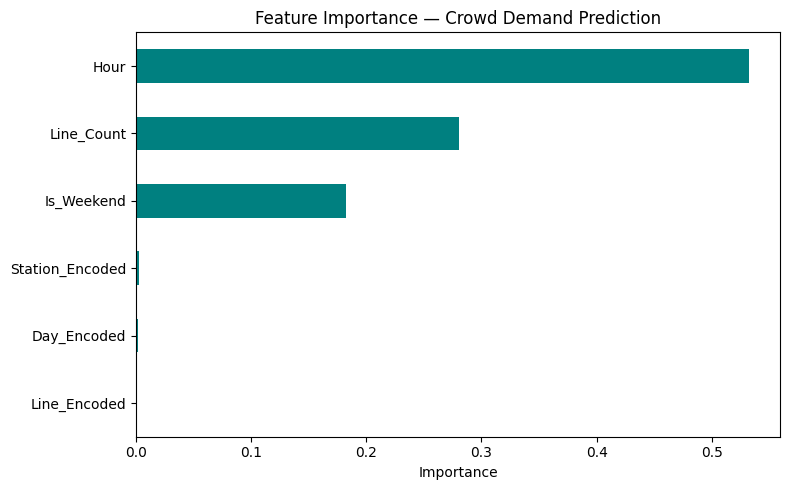

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="teal")
plt.title("Feature Importance \u2014 Crowd Demand Prediction")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
import joblib
import os

os.makedirs("../backend/app/ml_models", exist_ok=True)

joblib.dump(model, "../backend/app/ml_models/crowd_demand_model.pkl")
joblib.dump(le_station, "../backend/app/ml_models/station_encoder.pkl")
joblib.dump(le_line, "../backend/app/ml_models/line_encoder.pkl")
joblib.dump(le_day, "../backend/app/ml_models/day_encoder.pkl")

print("Model and encoders saved.")

Model and encoders saved.


In [21]:
demand_df.to_csv("data/synthetic_crowd_demand.csv", index=False)
print("Saved:", demand_df.shape)

Saved: (149340, 10)


In [1]:
import joblib

# Reload and re-save with compression
model_reloaded = joblib.load("../backend/app/ml_models/crowd_demand_model.pkl")
joblib.dump(model_reloaded, "../backend/app/ml_models/crowd_demand_model.pkl", compress=3)

import os
size_mb = os.path.getsize("../backend/app/ml_models/crowd_demand_model.pkl") / (1024 * 1024)
print(f"New model size: {size_mb:.2f} MB")

New model size: 43.26 MB
